# Expected $^{20}\text{Ne}$ Fusion Events

In [1]:
from spyral.core.constants import AMU_2_MEV, QBRHO_2_P

from spyral_utils.nuclear import NuclearDataMap
from spyral_utils.nuclear.target import GasTarget, load_target, SolidTarget
from spyral_utils.plot import Histogrammer
from scipy.constants import physical_constants, torr

import polars as pl
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import vector
import lmfit

%matplotlib widget
plt.close()

nuclear_map = NuclearDataMap()
# Ion Chamber entrance and exit window, thickness in ug/cm^2
ic_window_material = SolidTarget(compound=[[1,1,14],[6,12,14],[7,14,4],[8,16,4]], thickness=1422.312, nuclear_data=nuclear_map)
# AT-TPC entrance window, thickness in ug/cm^2
attpc_window_material = SolidTarget(compound=[[1,1,14],[6,12,14],[7,14,4],[8,16,4]], thickness=1422.312, nuclear_data=nuclear_map)
# Ion Chamber gas material, pressure in Torr
ic_gas_material = GasTarget(compound=[(6,12,1),(9,18,4)], pressure=200.0, nuclear_data=nuclear_map)
ic_gas_thickness = 0.035 #m


In [2]:
nuclear_map = NuclearDataMap()

# Set some parameters
# workspace_path_target = Path("/Volumes/research_EXT_2/spyral_target_alpha_width3")
# workspace_path_decay = Path("/Volumes/research_EXT_2/spyral_decay_alpha_width3")

# solver_result_path_target = workspace_path_target / "InterpSolver"
# solver_result_path_decay = workspace_path_decay / "InterpSolver"
solver_result_path = Path("/Volumes/researchEXT/O16/all_analysis_spyralv1.0/all_five_tracks_analysis/14082026_all_5tracks") / "InterpSolver"
# Your AT-TPC target gas material
target_material_path = Path("/Users/pranjalsingh/Desktop/research_space_spyral/e20020_analysis/solver_gas_16O.json")

# Run number range (inclusive)
run_min = 54
run_max = 170
# Specify your nuclei

# The nucleus we observe (the one we fitted)
ejectile_z = 2
ejectile_a = 4

# The incoming nucleus (the beam)
projectile_z = 8
projectile_a = 16

fusion_z = 10
fusion_a = 20

# The target nucleus
target_z = 2
target_a = 4

# We calculate the residual for you
residual_z = target_z + projectile_z - ejectile_z
residual_a = target_a + projectile_a - ejectile_a


if residual_z < 0:
    raise Exception(f"Illegal nuclei! Residual Z: {residual_z}")  # noqa: TRY002
if residual_a < 1:
    raise Exception(f"Illegal nuclei! Residual A: {residual_a}")  # noqa: TRY002


In [3]:
target_material = load_target(target_material_path, nuclear_map)
if not isinstance(target_material, GasTarget):
    print('Target error!')

ejectile = nuclear_map.get_data(ejectile_z, ejectile_a)
projectile = nuclear_map.get_data(projectile_z, projectile_a)
fusion = nuclear_map.get_data(fusion_z, fusion_a)
target = nuclear_map.get_data(target_z, target_a)
residual = nuclear_map.get_data(residual_z, residual_a)
print(f"Reaction: {target}({projectile}, {ejectile}){residual}")
print(f"Target material: {target_material.ugly_string}")

# Initial beam energy
mass_amu = projectile.mass / AMU_2_MEV # If needed, to convert beam energy in MeV/u -> MeV
proj_energy_accel = 161.0 # MeV, the beam energy from the accelerator

# The beam energy after the ic entrance window
proj_energy_ic = proj_energy_accel #- ic_window_material.get_energy_loss(projectile, proj_energy_accel, np.array([0.0]))[0]
# The beam energy after the ic gas
proj_energy_ic_exit = proj_energy_ic #- ic_gas_material.get_energy_loss(projectile, proj_energy_ic, np.array([ic_gas_thickness]))[0]
# The beam energy after the ic exit window
proj_energy_post_ic = proj_energy_ic_exit #- ic_window_material.get_energy_loss(projectile, proj_energy_ic_exit, np.array([0.0]))[0]
# The beam energy after the AT-TPC entrace window
proj_energy_start = proj_energy_post_ic #- attpc_window_material.get_energy_loss(projectile, proj_energy_post_ic, np.array([0.0]))[0]
# The beam energy at the downstream end of the AT-TPC
proj_energy_stop = proj_energy_start - target_material.get_energy_loss(projectile, proj_energy_start, np.array([1.0]))[0] # Energy at far end of detector
print(f"Accelerator Beam energy: {proj_energy_accel} MeV")
print(f"Beam energy after IC (2 windows + gas): {proj_energy_post_ic} MeV")
print(f"Beam energy range in AT-TPC: {proj_energy_start}-{proj_energy_stop} MeV")


Reaction: 4He(16O, 4He)16O
Target material: (Gas)4He1
Accelerator Beam energy: 161.0 MeV
Beam energy after IC (2 windows + gas): 161.0 MeV
Beam energy range in AT-TPC: 161.0-110.84634259864373 MeV


In [4]:
energy_halfway = proj_energy_start - target_material.get_energy_loss(projectile, proj_energy_start, np.array([0.5]))[0]
energy_gem = np.linspace(proj_energy_start,energy_halfway,20)
energy_gem_2half = np.linspace(energy_halfway,proj_energy_stop,10)
alpha_crosssec = np.array([5.77,5.181,4.529,3.828,3.565,
                            3.229,2.886,2.47,2.065,1.784,
                            1.519,1.374,1.036,0.8736,0.6463,
                            0.5203,0.4639,0.272,0.2275,0.1761,
                            ])


alpha_crosssec_2half = np.array([0.2344,0.111,0.02642,0,0,
                                0,0,0,0,0])

# print(energy_gem)
# print()
# print(energy_gem_2half)

In [5]:
from scipy.optimize import curve_fit
def exponential_decay(x, a, k, c):
    """
    a: Amplitude (initial value scale)
    k: Decay rate constant
    c: Vertical offset (asymptote)
    """
    return a * np.exp(-k * x) + c

Fitted Parameters:
 a = 1.30e-05
 k = -0.0817
 c = -0.9102


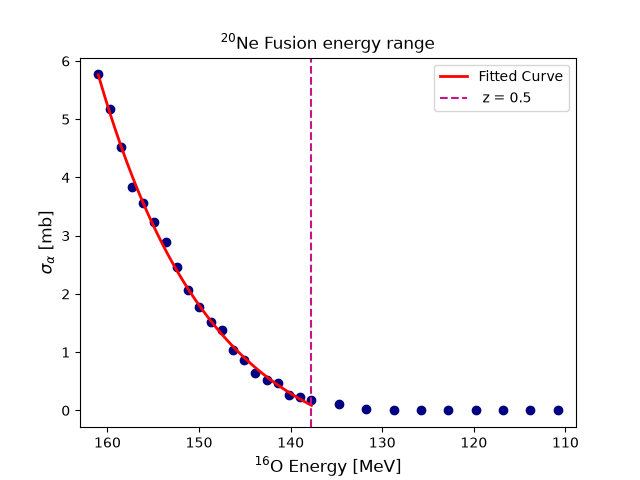

In [6]:
initial_guess = [1.3, -0.13, 0.0]
popt, pcov = curve_fit(exponential_decay, energy_gem, alpha_crosssec, p0=initial_guess)
fitted_a, fitted_k, fitted_c = popt

print(f"Fitted Parameters:\n a = {fitted_a:.2e}\n k = {fitted_k:.4f}\n c = {fitted_c:.4f}")

energy_gem_smooth = np.linspace(161,energy_halfway,100)

plt.scatter(energy_gem,alpha_crosssec,color="navy")
# print(energy_gem_2half,alpha_crosssec_2half)
plt.scatter(energy_gem_2half[1:],alpha_crosssec_2half[1:],color="navy")
plt.plot(energy_gem_smooth, exponential_decay(energy_gem_smooth, *popt), label='Fitted Curve', color='red', lw=2)

plt.axvline(x=energy_halfway, ymax=6, linestyle="--", color="mediumvioletred", label=" z = 0.5 ")
plt.title(r"$^{20}$Ne Fusion energy range")
plt.xlabel(r"$^{16}$O Energy [MeV]", fontsize=12)
plt.ylabel(r"$\sigma_\alpha$ [mb]", fontsize=12)
# plt.ylabel(r"$20$Ne Excitation energy [MeV]", fontsize=12)
# plt.ylim(-0.1,6)
# plt.xticks(energy_gem, [f"{x:.0f}" for x in energy_gem])
plt.xlim(max(energy_gem)+2, min(energy_gem_2half)-2) 
plt.legend()
plt.show()

## Expected 5 tracks (experimentally)

In [7]:
pressure = 700
torr_2_pascal = torr 
length = 1
boltzmann = physical_constants["Boltzmann constant"][0]    # Units of Joules / Kelvin
temperature = 293.15  
stoich = 1

beam_counts = 300967*20000 #matched from the amplitude of elastic
nuclei_areal_density = 2.26E-6
absolute_expected = (nuclei_areal_density)*(beam_counts)*alpha_crosssec
absolute_expected_2nd = (nuclei_areal_density)*(beam_counts)*alpha_crosssec_2half[1:]


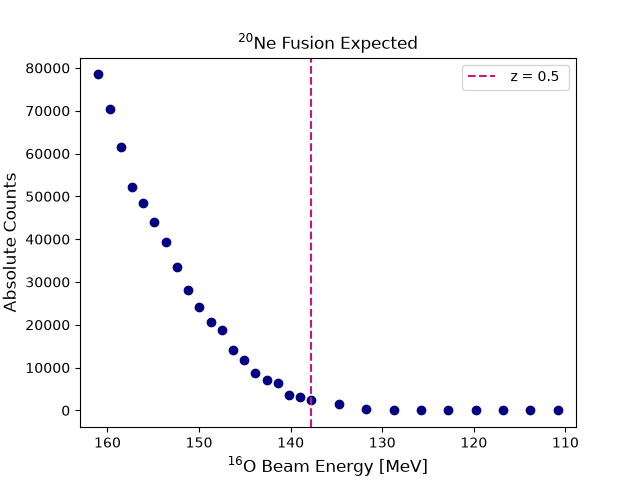

In [9]:
fig,ax = plt.subplots()
ax.scatter(energy_gem,absolute_expected,color="navy")
ax.scatter(energy_gem_2half[1:],absolute_expected_2nd,color="navy")

ax.axvline(x=energy_halfway, ymax=6, linestyle="--", color="mediumvioletred", label=" z = 0.5 ")
ax.set_title(r"$^{20}$Ne Fusion Expected")
ax.set_xlabel(r"$^{16}$O Beam Energy [MeV]", fontsize=12)
ax.set_ylabel(r"Absolute Counts", fontsize=12)
ax.set_xlim(max(energy_gem)+2, min(energy_gem_2half)-2) 
# ax.set_yscale("log") 

plt.legend()
plt.show()